In [1]:
# Verbindung zu Google Drive aufbauen
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install geopandas rasterio shapely

In [4]:
!pip install jenkspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.0/642.0 kB 9.4 MB/s eta 0:00:00


In [5]:
# Imports
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib as mpl
import matplotlib.pyplot as plt
import jenkspy
from matplotlib.colors import ListedColormap, BoundaryNorm
from rasterio.mask import mask as rio_mask
from shapely.ops import unary_union
from matplotlib.patches import Patch
from pyproj import Transformer


In [6]:
# APA 7 konforme Abbildungen

# Schrift
mpl.rcParams["font.family"]      = "serif"
mpl.rcParams["font.serif"]  = ["Liberation Serif", "DejaVu Serif", "Georgia"]
mpl.rcParams["font.size"]        = 12       # Grundschriftgröße
mpl.rcParams["axes.titlesize"]   = 12       # Titel
mpl.rcParams["axes.labelsize"]   = 11       # Achsenbeschriftung
mpl.rcParams["xtick.labelsize"]  = 10       # X-Achse Ticks
mpl.rcParams["ytick.labelsize"]  = 10       # Y-Achse Ticks
mpl.rcParams["legend.fontsize"]  = 10       # Legende
mpl.rcParams["figure.titlesize"] = 12       # Suptitle

# Linien & Achsen
mpl.rcParams["axes.linewidth"]   = 0.8      # Achsenrahmen
mpl.rcParams["xtick.major.width"]= 0.8
mpl.rcParams["ytick.major.width"]= 0.8
mpl.rcParams["lines.linewidth"]  = 1.0

# Hintergrund & Gitter
mpl.rcParams["axes.facecolor"]   = "white"
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.grid"]        = False    # APA: kein Gitter

# Abbildungsgröße & Auflösung
mpl.rcParams["figure.dpi"]       = 150
mpl.rcParams["savefig.dpi"]      = 300      # APA: mind. 300 dpi beim Speichern
mpl.rcParams["savefig.bbox"]     = "tight"
mpl.rcParams["savefig.format"]   = "png"

# Legende
mpl.rcParams["legend.frameon"]       = False   # APA: kein Rahmen um Legende
mpl.rcParams["legend.loc"]           = "best"

print("✅ APA 7 Stil gesetzt – Times New Roman, 300 dpi, kein Gitter")

✅ APA 7 Stil gesetzt – Times New Roman, 300 dpi, kein Gitter


In [7]:
# Rasterladen, Differenzen erstellen, auf Wue clippen und nach Wohnbaufläche selektieren
# ── Pfade ────────────────────────────────────────────────────────────────────
base    = "/content/drive/MyDrive/Colab_Notebooks"
shp_path = f"{base}/ALKIS/ALKIS_Stadt_Wue/ALKIS_Stadt_Wue.shp"
NODATA  = -9999.0

shapefiles = {
    "Rottenbauer-Nord":    f"{base}/Shapefiles_Gebiete/Rottenbauer/Shape_Rottenbauer_Nord.shp",
    "Rottenbauer-Süd":     f"{base}/Shapefiles_Gebiete/Rottenbauer/Shape_Rottenbauer_alt.shp",
    "Lengfeld":            f"{base}/Shapefiles_Gebiete/Lengfeld/Shape_Lengfeld.shp",
    "Lengfeld-Kern":       f"{base}/Shapefiles_Gebiete/Lengfeld/Shape_Lengfeld_alt.shp",
    "Hubland Grünfläche":  f"{base}/Shapefiles_Gebiete/Hubland/Shape_Hubland_Gruenflaeche.shp",
    "Hubland Terrassen":   f"{base}/Shapefiles_Gebiete/Hubland/Shape_Hublandterrassen.shp",
    "Hubland Quartier I":  f"{base}/Shapefiles_Gebiete/Hubland/Shape_Quartier_I.shp",
    "Hubland Quartier II": f"{base}/Shapefiles_Gebiete/Hubland/Shape_Quartier_II_plus_BBP_70.shp",
    "Hubland Quartier III":f"{base}/Shapefiles_Gebiete/Hubland/Shape_Quartier_III.shp",
    "Gartenstadt":         f"{base}/Shapefiles_Gebiete/Gartenstadt/Shape_Gartenstadt.shp",
}

# ── Gebiete laden + Hubland-Gesamt ergänzen ──────────────────────────────────
gebiete = {name: gpd.read_file(path) for name, path in shapefiles.items()}

hubland_keys = ["Hubland Grünfläche", "Hubland Terrassen",
                "Hubland Quartier I", "Hubland Quartier II", "Hubland Quartier III"]

hubland_gesamt = gpd.GeoDataFrame(
    geometry=[pd.concat([gebiete[k].geometry for k in hubland_keys]).union_all()],
    crs=gebiete[hubland_keys[0]].crs
)

# Hubland-Gesamt nach Quartier III einfügen
gebiete_final = {}
for name, gdf in gebiete.items():
    gebiete_final[name] = gdf
    if name == "Hubland Quartier III":
        gebiete_final["Hubland-Gesamt"] = hubland_gesamt

# ── GHSL-Rasterpfade ─────────────────────────────────────────────────────────
ghsl_dir = f"{base}/GHSL"
file_paths = {
    "S2005": f"{ghsl_dir}/GHS_BUILT_S_E2005_GLOBE_R2023A_54009_100_V1_0_R4_C19.tif",
    "S2015": f"{ghsl_dir}/GHS_BUILT_S_E2015_GLOBE_R2023A_54009_100_V1_0_R4_C19.tif",
    "S2025": f"{ghsl_dir}/GHS_BUILT_S_E2025_GLOBE_R2023A_54009_100_V1_0_R4_C19.tif",
    "V2005": f"{ghsl_dir}/GHS_BUILT_V_E2005_GLOBE_R2023A_54009_100_V1_0_R4_C19.tif",
    "V2015": f"{ghsl_dir}/GHS_BUILT_V_E2015_GLOBE_R2023A_54009_100_V1_0_R4_C19.tif",
    "V2025": f"{ghsl_dir}/GHS_BUILT_V_E2025_GLOBE_R2023A_54009_100_V1_0_R4_C19.tif",
}

# ── Hilfsfunktionen ───────────────────────────────────────────────────────────
def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
    return data

def save_diff(output_path, array, meta):
    meta.update({"dtype": "float32", "count": 1, "nodata": np.nan})
    with rasterio.open(output_path, "w", **meta) as dst:
        dst.write(array.astype("float32"), 1)

def clip_and_save(src_paths, mask_gdf, out_dir, suffix):
    """Clippt eine Liste von Rastern auf mask_gdf und speichert sie in out_dir."""
    for path in src_paths:
        with rasterio.open(path) as src:
            geom    = mask_gdf.to_crs(src.crs).geometry.values
            clipped, transform = mask(src, geom, crop=True)
            clipped = clipped[0].astype("float32")
            if src.nodata is not None:
                clipped[clipped == src.nodata] = np.nan
            meta = src.meta.copy()
            meta.update({"height": clipped.shape[0], "width": clipped.shape[1],
                         "transform": transform, "nodata": np.nan, "dtype": "float32"})
            fname    = path.split("/")[-1].replace(".tif", f"{suffix}.tif")
            with rasterio.open(f"{out_dir}/{fname}", "w", **meta) as dst:
                dst.write(clipped, 1)

# ── Differenzen berechnen & speichern ────────────────────────────────────────
diffs = {
    "diff_s_2025_2015": (read_raster(file_paths["S2025"]) - read_raster(file_paths["S2015"]), file_paths["S2025"]),
    "diff_s_2025_2005": (read_raster(file_paths["S2025"]) - read_raster(file_paths["S2005"]), file_paths["S2025"]),
    "diff_v_2025_2015": (read_raster(file_paths["V2025"]) - read_raster(file_paths["V2015"]), file_paths["V2025"]),
    "diff_v_2025_2005": (read_raster(file_paths["V2025"]) - read_raster(file_paths["V2005"]), file_paths["V2025"]),
}

for name, (array, ref_path) in diffs.items():
    with rasterio.open(ref_path) as src:
        meta = src.meta.copy()
    save_diff(f"{ghsl_dir}/{name}.tif", array, meta)

diff_paths = [f"{ghsl_dir}/{n}.tif" for n in diffs]

# ── Stadt-Shapefile laden & auf Raster-CRS bringen (einmalig) ────────────────
with rasterio.open(file_paths["S2005"]) as src:
    raster_crs = src.crs

stadt = gpd.read_file(shp_path).to_crs(raster_crs)
print("CRS Shapefile:", stadt.crs)

# ── Clip 1: gesamte Stadt ────────────────────────────────────────────────────
clip_and_save(diff_paths, stadt, f"{ghsl_dir}/Clipped", "_clip")
print("Clipping (Stadt) abgeschlossen")

# ── Clip 2: nur Wohnbauflächen ───────────────────────────────────────────────
stadt_wohn = stadt[stadt["nutzart"] == "Wohnbaufläche"]
clipped_paths = [f"{ghsl_dir}/Clipped/{n}_clip.tif" for n in diffs]

clip_and_save(clipped_paths, stadt_wohn, f"{ghsl_dir}/Clipped_Wohnbau", "_clip_Wohnbau")
print("Clipping (Wohnbauflächen) abgeschlossen")

CRS Shapefile: PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Clipping (Stadt) abgeschlossen
Clipping (Wohnbauflächen) abgeschlossen


Surface-Jenks-Breaks: [np.float64(0.0), np.float64(109.0), np.float64(332.0), np.float64(697.0), np.float64(1481.0), np.float64(3952.0)]
Volume-Jenks-Breaks: [np.float64(0.0), np.float64(1071.0), np.float64(3535.0), np.float64(9474.0), np.float64(18243.0), np.float64(31920.0)]


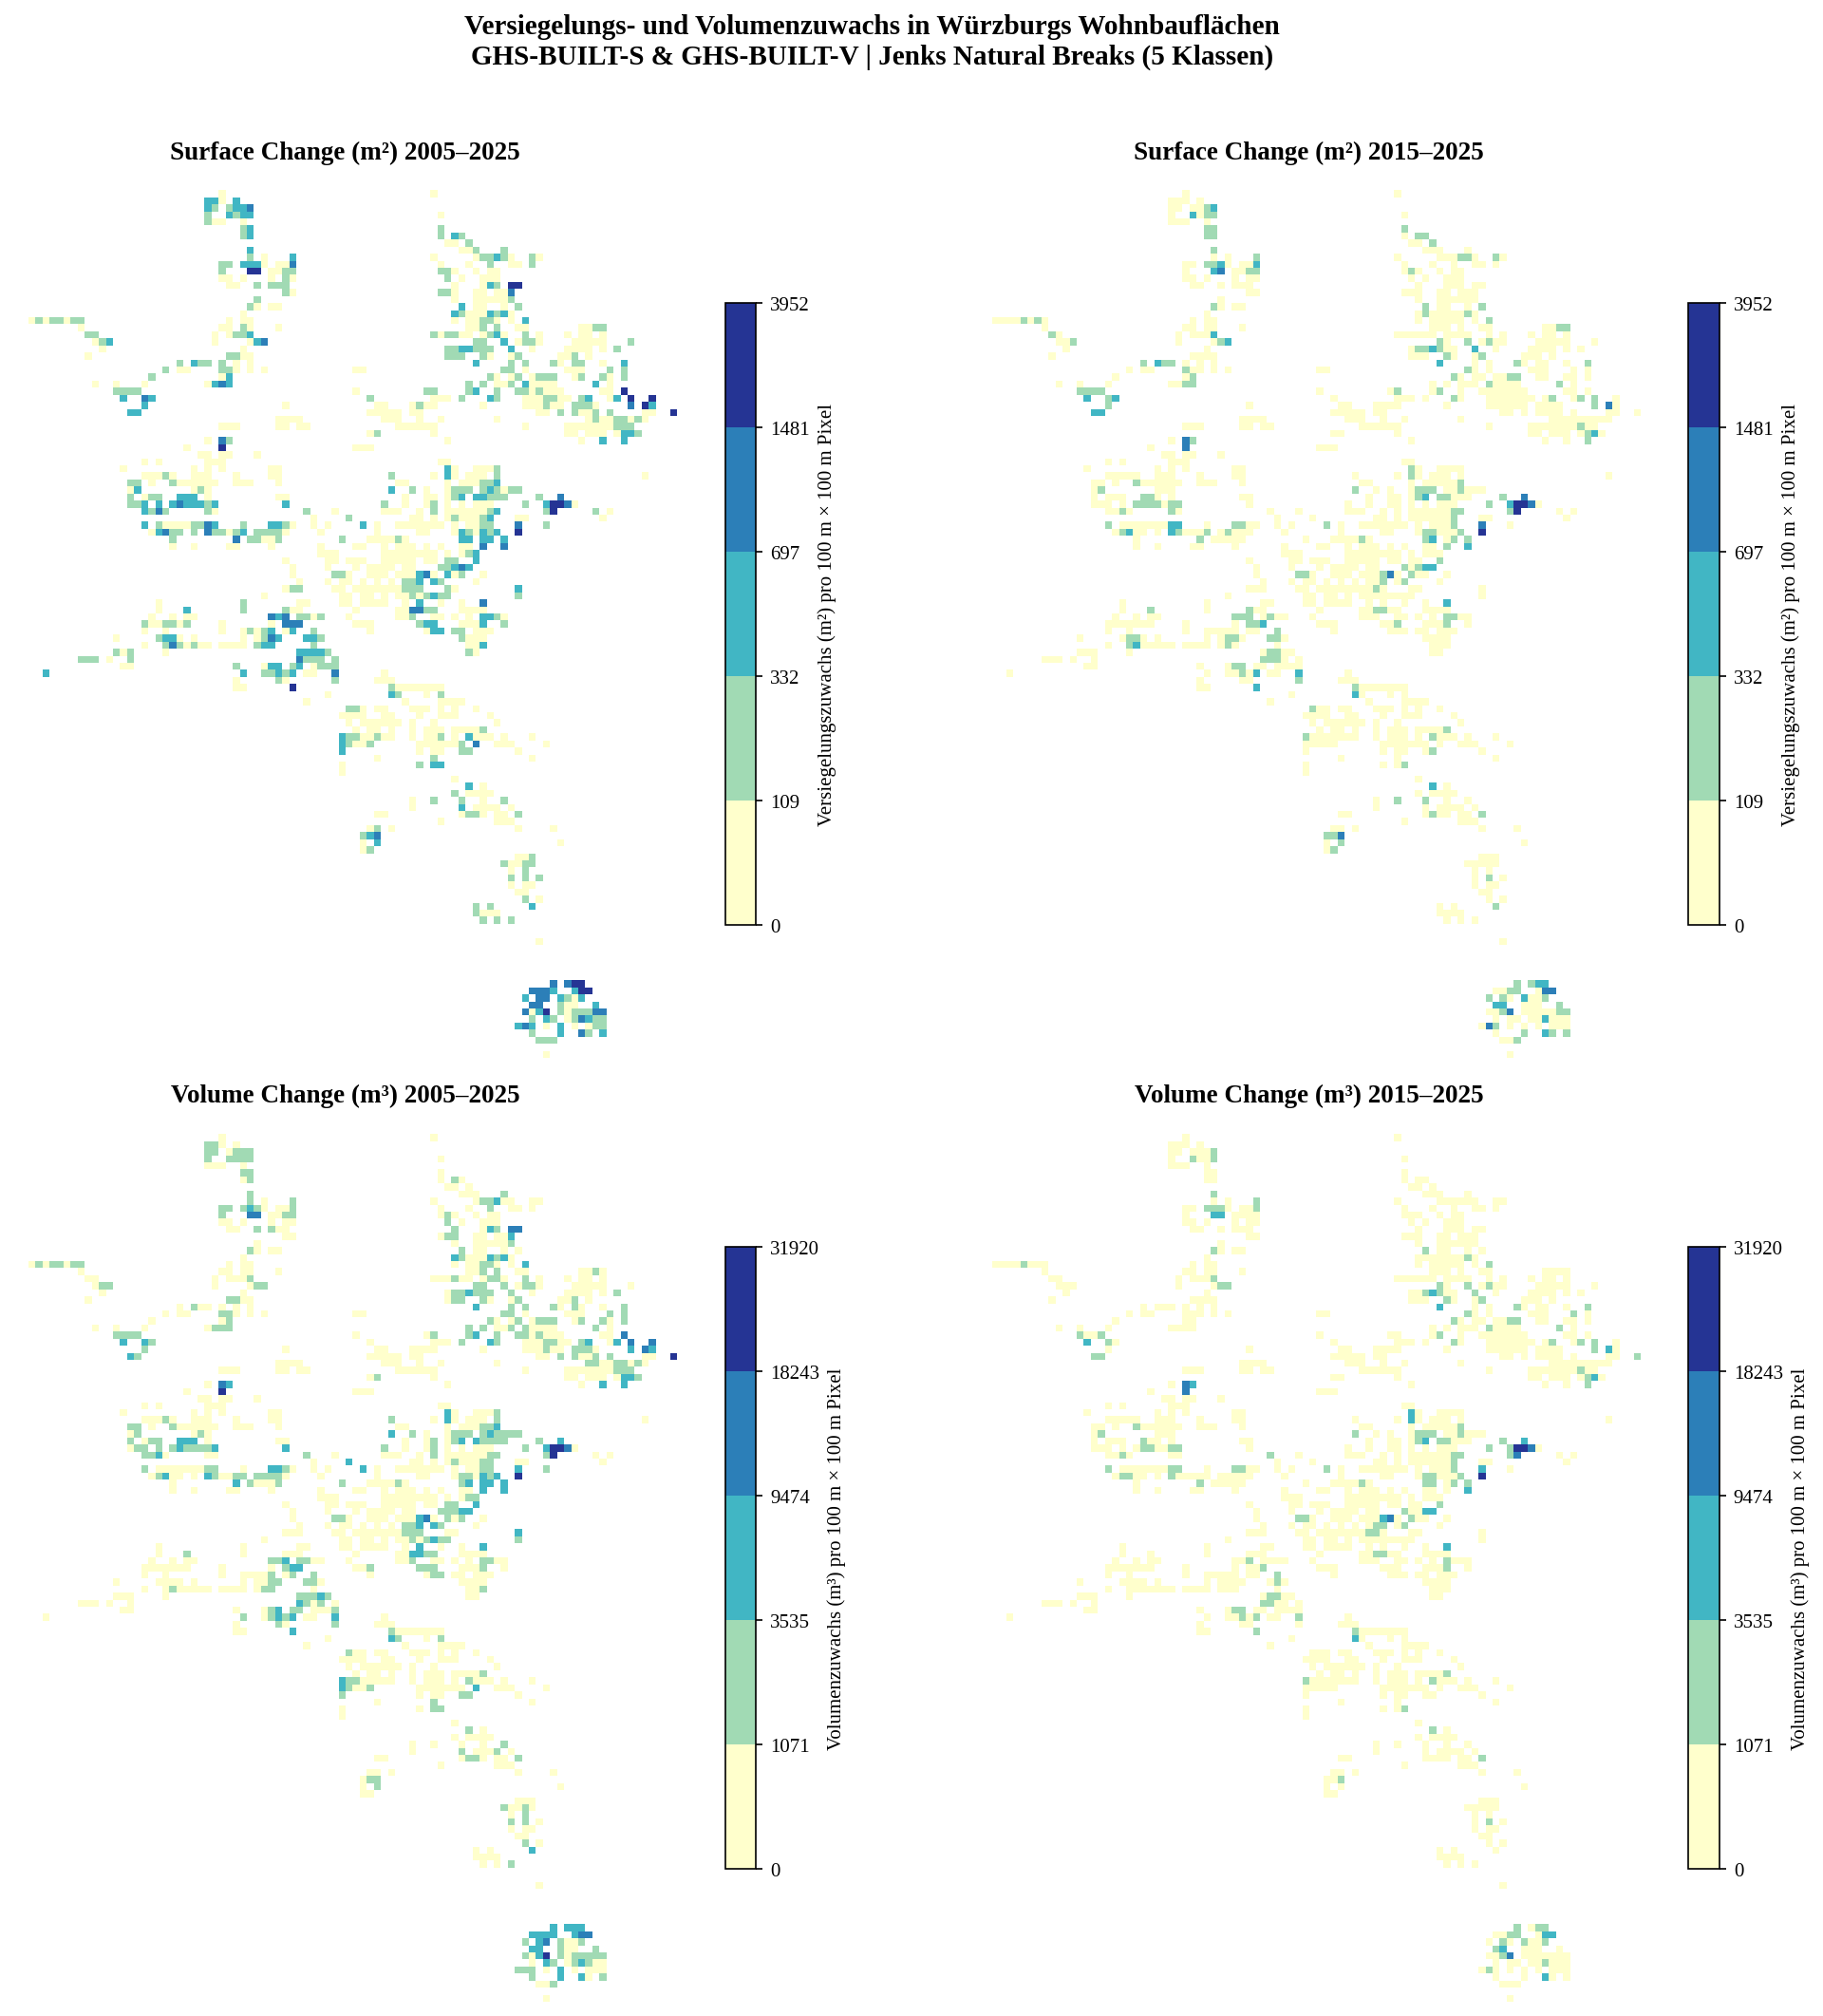

✅ Grafik gespeichert!


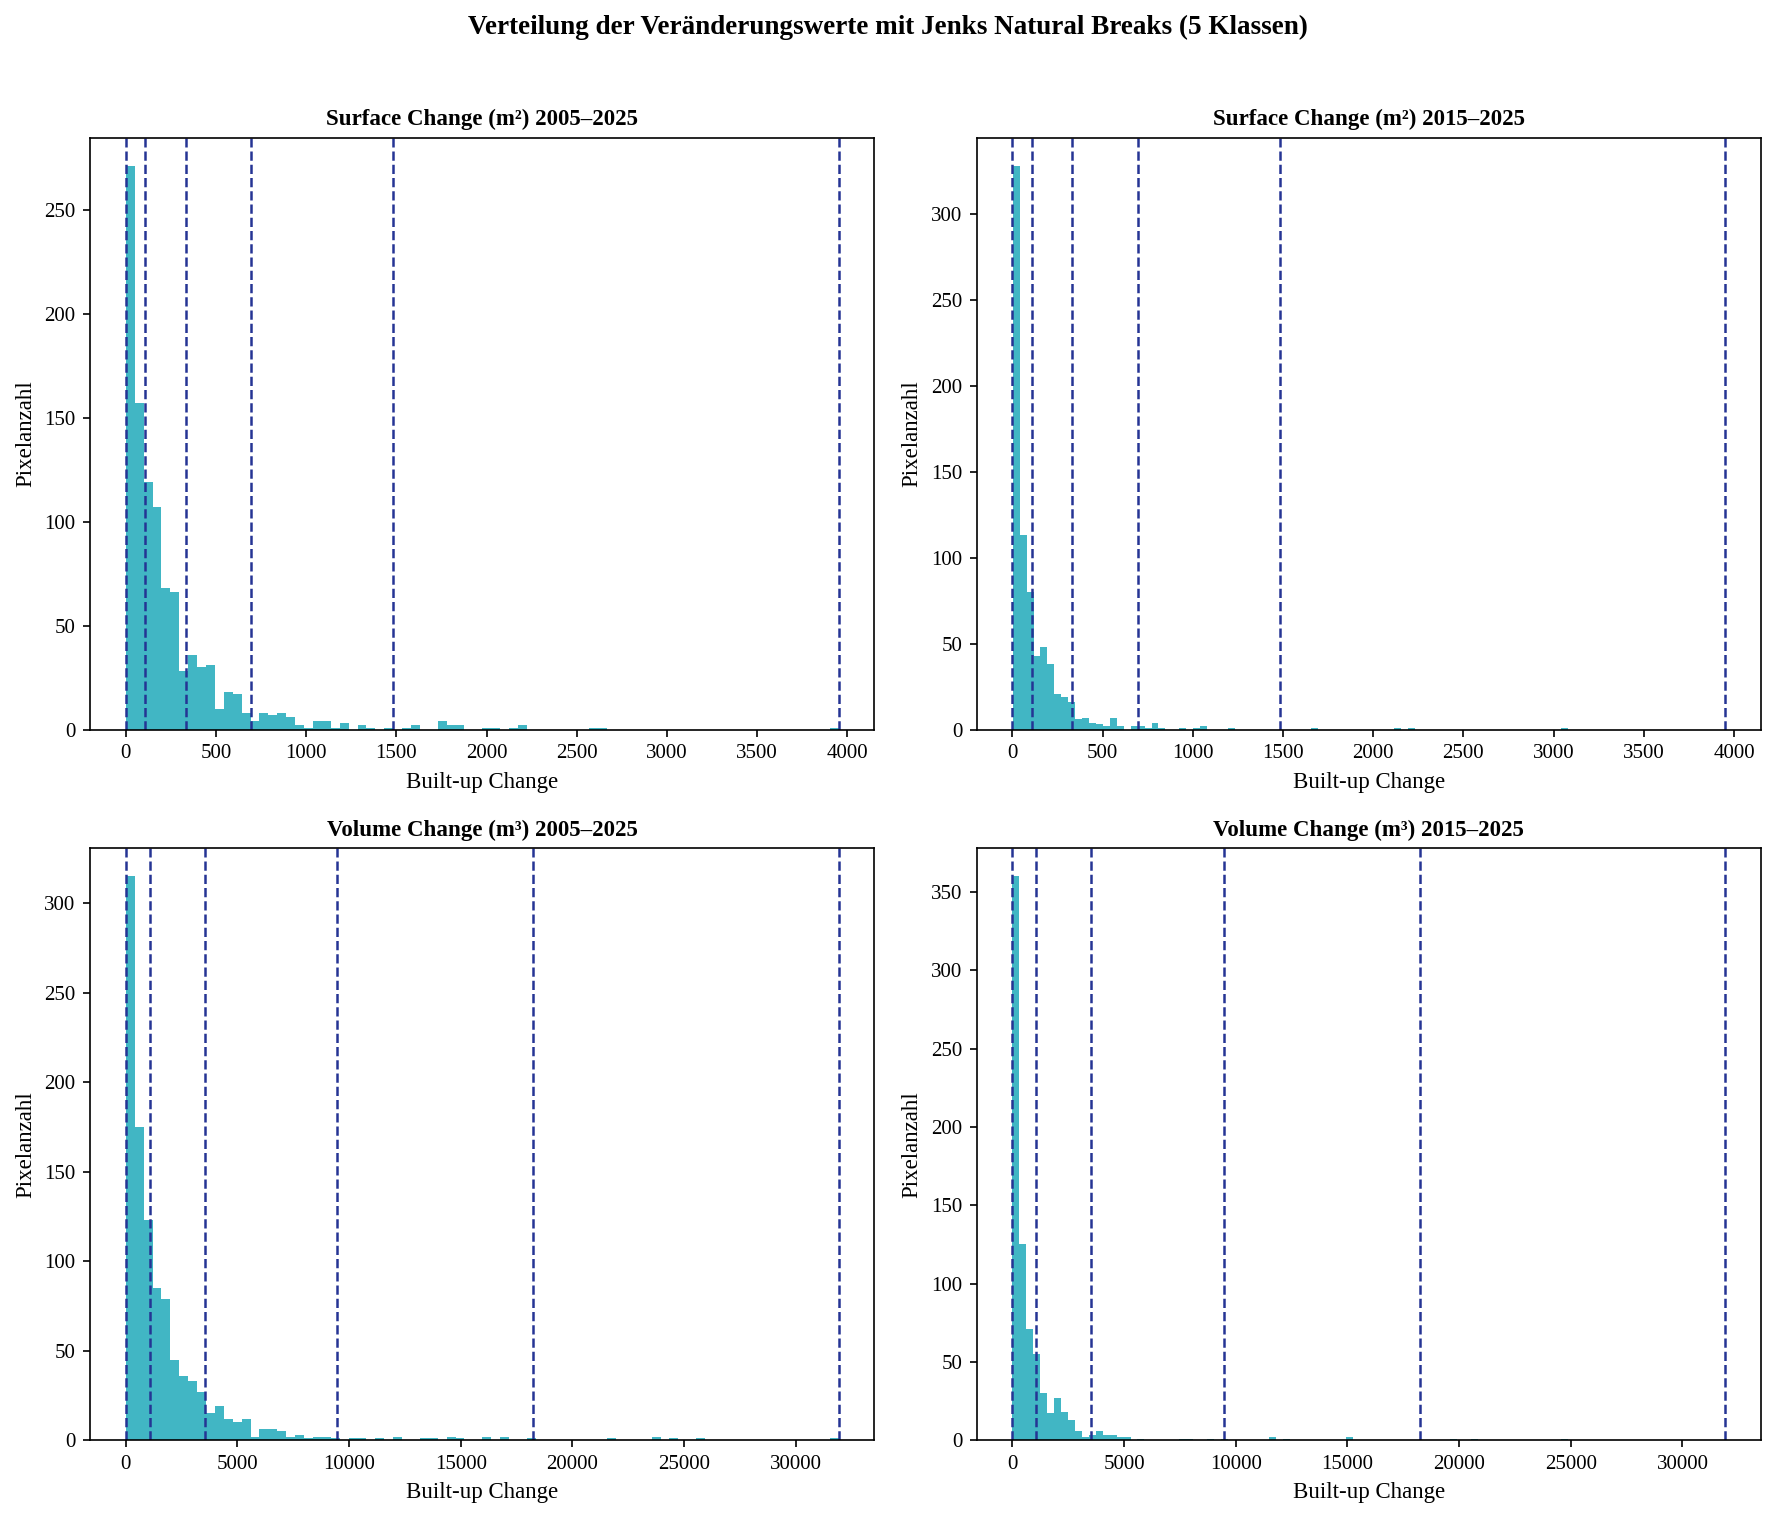

✅ Histogramme gespeichert!


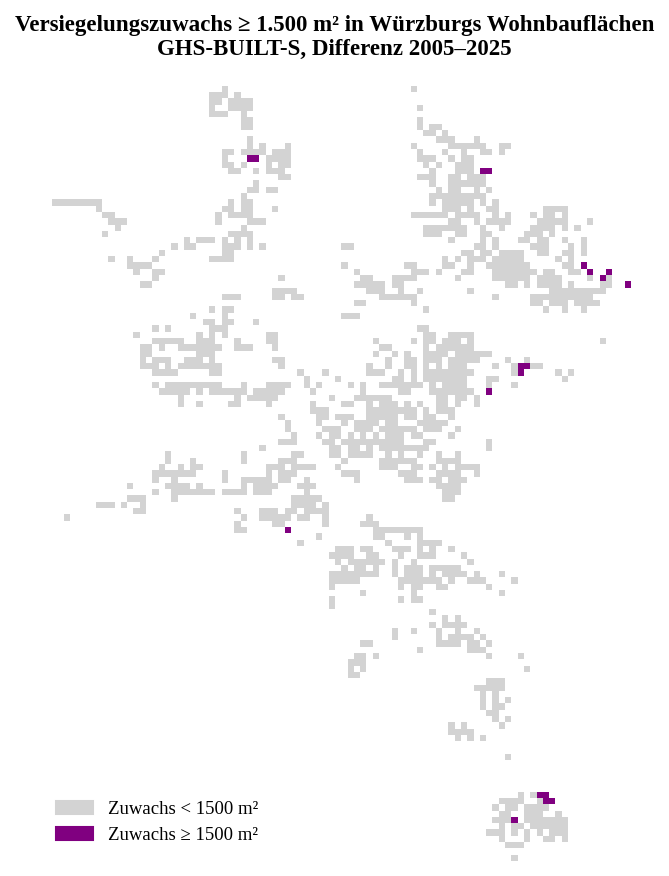

✅ Grafik gespeichert: GHSL_Schwellenwert_1500.png


In [15]:
# Erste Übersichts Histogramme und Karte # Schwellenwertkarte
# ── Pfade & Verzeichnisse ─────────────────────────────────────────────────────
wohnbau_dir = f"{base}/GHSL/Clipped_Wohnbau"
grafik_dir  = f"{base}/GHSL/Grafiken"
out_ghsl  = f"{base}/GHSL/clipped/"
os.makedirs(grafik_dir, exist_ok=True)

# ── Raster laden (einmalig) ───────────────────────────────────────────────────
def load_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
    return data

datasets = {
    "Surface 2005–2025": load_raster(f"{wohnbau_dir}/diff_s_2025_2005_clip_clip_Wohnbau.tif"),
    "Surface 2015–2025": load_raster(f"{wohnbau_dir}/diff_s_2025_2015_clip_clip_Wohnbau.tif"),
    "Volume 2005–2025":  load_raster(f"{wohnbau_dir}/diff_v_2025_2005_clip_clip_Wohnbau.tif"),
    "Volume 2015–2025":  load_raster(f"{wohnbau_dir}/diff_v_2025_2015_clip_clip_Wohnbau.tif"),
}
arr = list(datasets.values())

# ── Jenks Natural Breaks ──────────────────────────────────────────────────────
def valid_values(*arrays):
    return np.concatenate([a[~np.isnan(a)] for a in arrays])

n_classes      = 5
surface_breaks = jenkspy.jenks_breaks(valid_values(arr[0], arr[1]), n_classes)
volume_breaks  = jenkspy.jenks_breaks(valid_values(arr[2], arr[3]), n_classes)
print("Surface-Jenks-Breaks:", surface_breaks)
print("Volume-Jenks-Breaks:",  volume_breaks)

# ── Farbskala & Normalisierung ────────────────────────────────────────────────
colors       = ["#ffffcc", "#a1dab4", "#41b6c4", "#2c7fb8", "#253494"]
cmap         = ListedColormap(colors)
norms        = [BoundaryNorm(surface_breaks, cmap.N)] * 2 + [BoundaryNorm(volume_breaks, cmap.N)] * 2
breaks_list  = [surface_breaks, surface_breaks, volume_breaks, volume_breaks]

titles = [
    "Surface Change (m²) 2005–2025",
    "Surface Change (m²) 2015–2025",
    "Volume Change (m³) 2005–2025",
    "Volume Change (m³) 2015–2025",
]
cbar_labels = [
    "Versiegelungszuwachs (m²) pro 100 m × 100 m Pixel",
    "Versiegelungszuwachs (m²) pro 100 m × 100 m Pixel",
    "Volumenzuwachs (m³) pro 100 m × 100 m Pixel",
    "Volumenzuwachs (m³) pro 100 m × 100 m Pixel",
]

# ── 2×2 Kartenplot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for i, ax in enumerate(axes.flat):
    im = ax.imshow(arr[i], cmap=cmap, norm=norms[i])
    ax.set_title(titles[i], fontsize=13, fontweight="bold")
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.7).set_label(cbar_labels[i], fontsize=10)

fig.suptitle(
    "Versiegelungs- und Volumenzuwachs in Würzburgs Wohnbauflächen\n"
    "GHS-BUILT-S & GHS-BUILT-V | Jenks Natural Breaks (5 Klassen)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(f"{grafik_dir}/GHSL_Surface_Volume_Change.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Grafik gespeichert!")
# ── 2×2 Histogramme mit Jenks-Linien ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, ax in enumerate(axes.flat):
    values = arr[i]
    values = values[(~np.isnan(values)) & (values > 0)]
    ax.hist(values, bins=80, color="#41b6c4", edgecolor="none")
    for b in breaks_list[i]:
        ax.axvline(b, color="#253494", linewidth=1.2, linestyle="--")
    ax.set_title(titles[i], fontsize=11, fontweight="bold")
    ax.set_xlabel("Built-up Change")
    ax.set_ylabel("Pixelanzahl")

fig.suptitle(
    "Verteilung der Veränderungswerte mit Jenks Natural Breaks (5 Klassen)",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(f"{grafik_dir}/GHSL_Histogramme_Jenks.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Histogramme gespeichert!")

# ── Schwellenwert-Karte (≥ 1500 m²) ──────────────────────────────────────────
threshold  = 1500
surface    = arr[0]  # Surface 2005–2025 bereits geladen

classified = np.full(surface.shape, np.nan)
classified[~np.isnan(surface) & (surface < threshold)]  = 1  # grau
classified[~np.isnan(surface) & (surface >= threshold)] = 2  # lila

cmap_thresh = ListedColormap(["lightgrey", "purple"])
norm_thresh = BoundaryNorm([1, 2, 3], cmap_thresh.N)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(classified, cmap=cmap_thresh, norm=norm_thresh)
ax.set_title(
    "Versiegelungszuwachs ≥ 1.500 m² in Würzburgs Wohnbauflächen\n"
    "GHS-BUILT-S, Differenz 2005–2025",
    fontsize=11, fontweight="bold"
)
ax.axis("off")
ax.legend(
    handles=[
        Patch(color="lightgrey", label=f"Zuwachs < {threshold} m²"),
        Patch(color="purple",    label=f"Zuwachs ≥ {threshold} m²"),
    ],
    loc="lower left", fontsize=9, framealpha=0.9
)
plt.tight_layout()
plt.savefig(f"{grafik_dir}/GHSL_Schwellenwert_1500.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Grafik gespeichert: GHSL_Schwellenwert_1500.png")





In [ ]:
# Koordinaten für herausgilterten Gebiete

# Koordinaten extrahieren
def pixel_to_dms(lon, lat):
    """Dezimalgrad → Grad°Minuten'Sekunden\" Format"""
    def to_dms(value, pos_label, neg_label):
        direction = pos_label if value >= 0 else neg_label
        value = abs(value)
        degrees = int(value)
        minutes = int((value - degrees) * 60)
        seconds = ((value - degrees) * 60 - minutes) * 60
        return f'{degrees}°{minutes:02d}\'{seconds:05.2f}"{direction}'

    return f'{to_dms(lat, "N", "S")} {to_dms(lon, "E", "W")}'


# Transformer: Mollweide → WGS84
transformer = Transformer.from_crs("ESRI:54009", "EPSG:4326", always_xy=True)

# Pixel-Indizes aller Pixel mit Surface Change >= 1500
rows, cols = np.where((~np.isnan(surface)) & (surface >= threshold))

# Georeferenzierung aus dem Raster lesen
with rasterio.open(f"{base}/GHSL/Clipped_Wohnbau/diff_s_2025_2005_clip_clip_Wohnbau.tif") as src:
    transform = src.transform

# Pixel-Mittelpunkte in Mollweide-Koordinaten (Meter)
xs, ys = rasterio.transform.xy(transform, rows, cols)

# Umrechnung nach WGS84
lons, lats = transformer.transform(xs, ys)

# DMS-Koordinaten ausgeben
coords_dms = [pixel_to_dms(lon, lat) for lon, lat in zip(lons, lats)]

for coord in coords_dms:
    print(coord)

49°49'20.27"N 9°55'18.88"E
49°49'20.27"N 9°55'23.60"E
49°49'13.40"N 9°58'12.70"E
49°49'13.40"N 9°58'17.42"E
49°48'21.91"N 9°59'21.54"E
49°48'18.48"N 9°59'25.81"E
49°48'18.48"N 9°59'39.98"E
49°48'15.05"N 9°59'34.81"E
49°48'11.61"N 9°59'53.24"E
49°47'26.99"N 9°58'27.19"E
49°47'26.99"N 9°58'31.91"E
49°47'23.56"N 9°58'26.75"E
49°47'13.26"N 9°58'01.81"E
49°45'57.76"N 9°55'21.02"E
49°43'33.66"N 9°58'11.07"E
49°43'33.66"N 9°58'15.79"E
49°43'30.23"N 9°58'15.35"E
49°43'30.23"N 9°58'20.06"E
49°43'19.94"N 9°57'50.43"E


✅ 8 GHSL-Rohdateien gefunden:
  ✔ GHS_BUILT_S_E2005_GLOBE_R2023A_54009_100_V1_0_R4_C19.tif → geclippt
  ✔ GHS_BUILT_S_E2025_GLOBE_R2023A_54009_100_V1_0_R4_C19.tif → geclippt
  ✔ GHS_BUILT_V_E2005_GLOBE_R2023A_54009_100_V1_0_R4_C19.tif → geclippt
  ✔ GHS_BUILT_V_E2025_GLOBE_R2023A_54009_100_V1_0_R4_C19.tif → geclippt
  ✔ diff_s_2025_2005.tif → geclippt
  ✔ diff_s_2025_2015.tif → geclippt
  ✔ diff_v_2025_2005.tif → geclippt
  ✔ diff_v_2025_2015.tif → geclippt

Gebiet                         Ø 2005        Ø 2025         Ø Diff   Σ 2005 (ha)   Σ 2025 (ha)   Σ Diff (ha)
  Rottenbauer-Nord               1970.6         2690.4         +818.3          7.49         10.76         +3.27
  Rottenbauer-Süd                2826.9         3139.4         +312.5         11.31         12.56         +1.25
  Lengfeld                       1817.2         2980.6        +1264.3          3.09          5.36         +2.28
  Lengfeld-Kern                  3298.1         3446.7         +162.8          7.59         

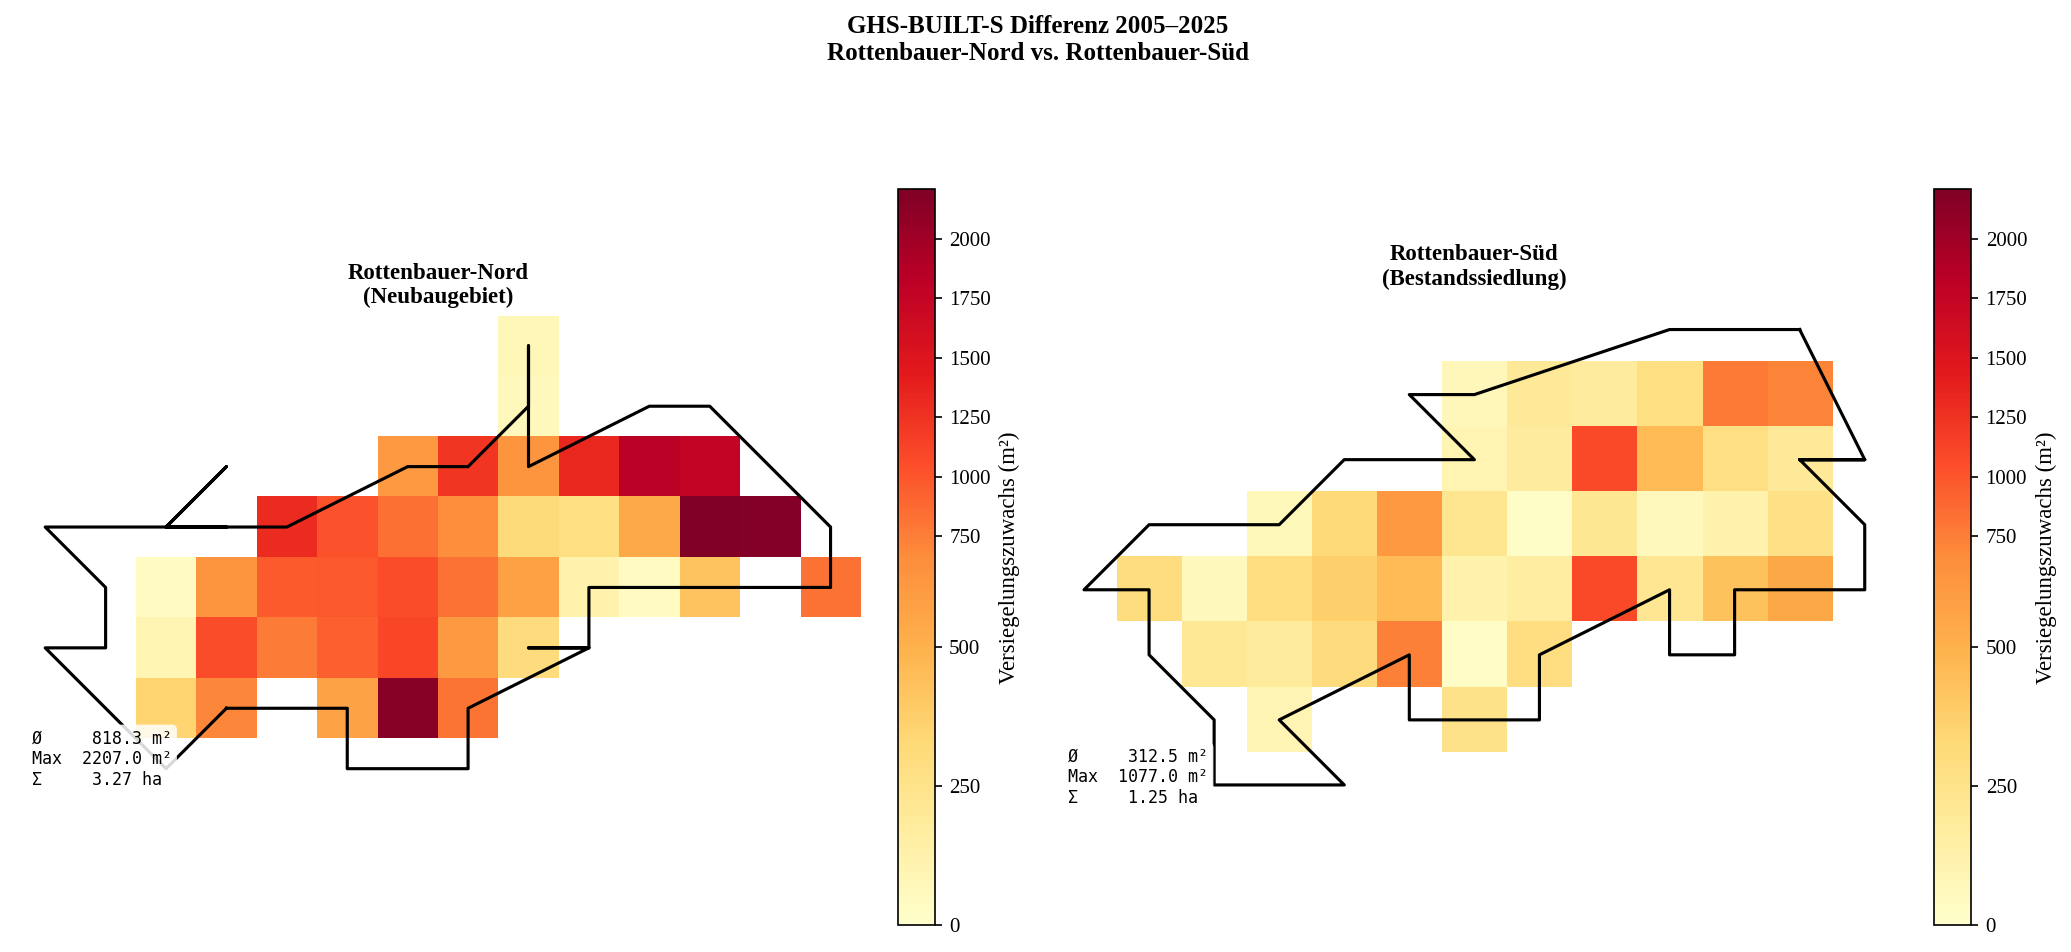

✅ Gespeichert: GHSL_Diff_Rottenbauer-Nord_Rottenbauer-Süd.png


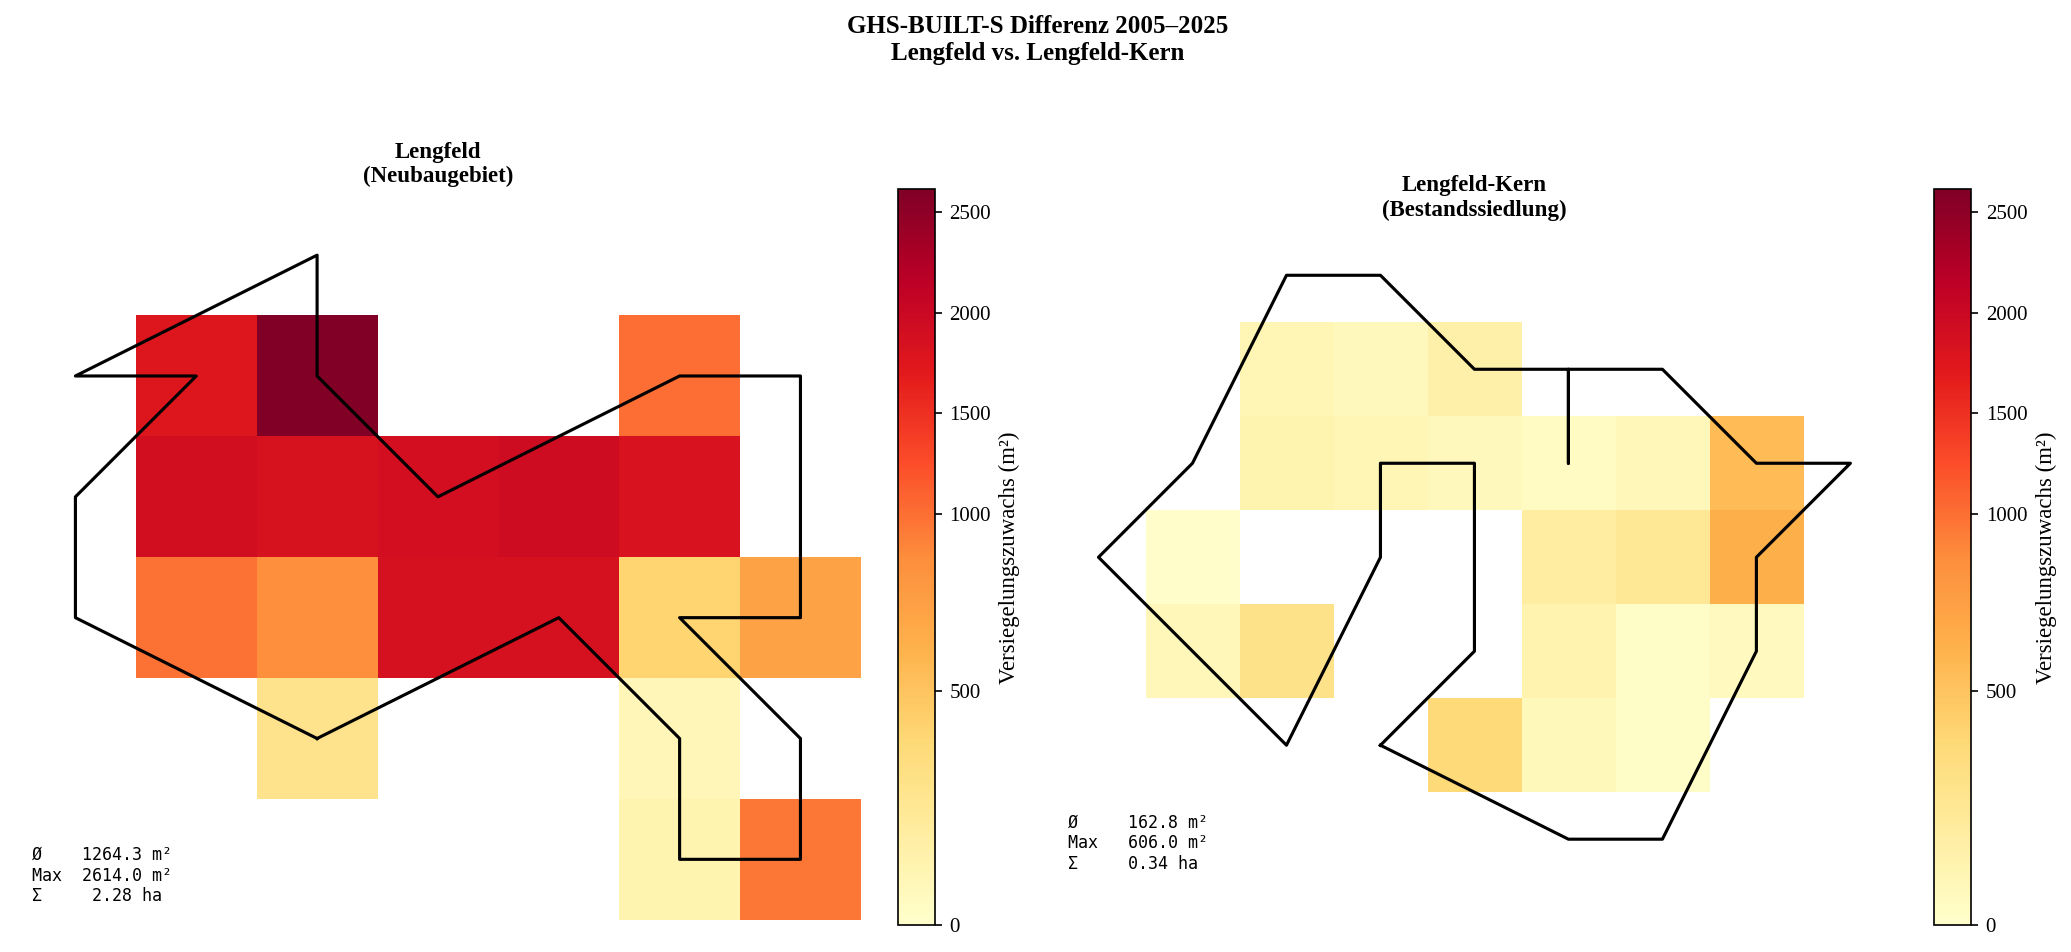

✅ Gespeichert: GHSL_Diff_Lengfeld_Lengfeld-Kern.png


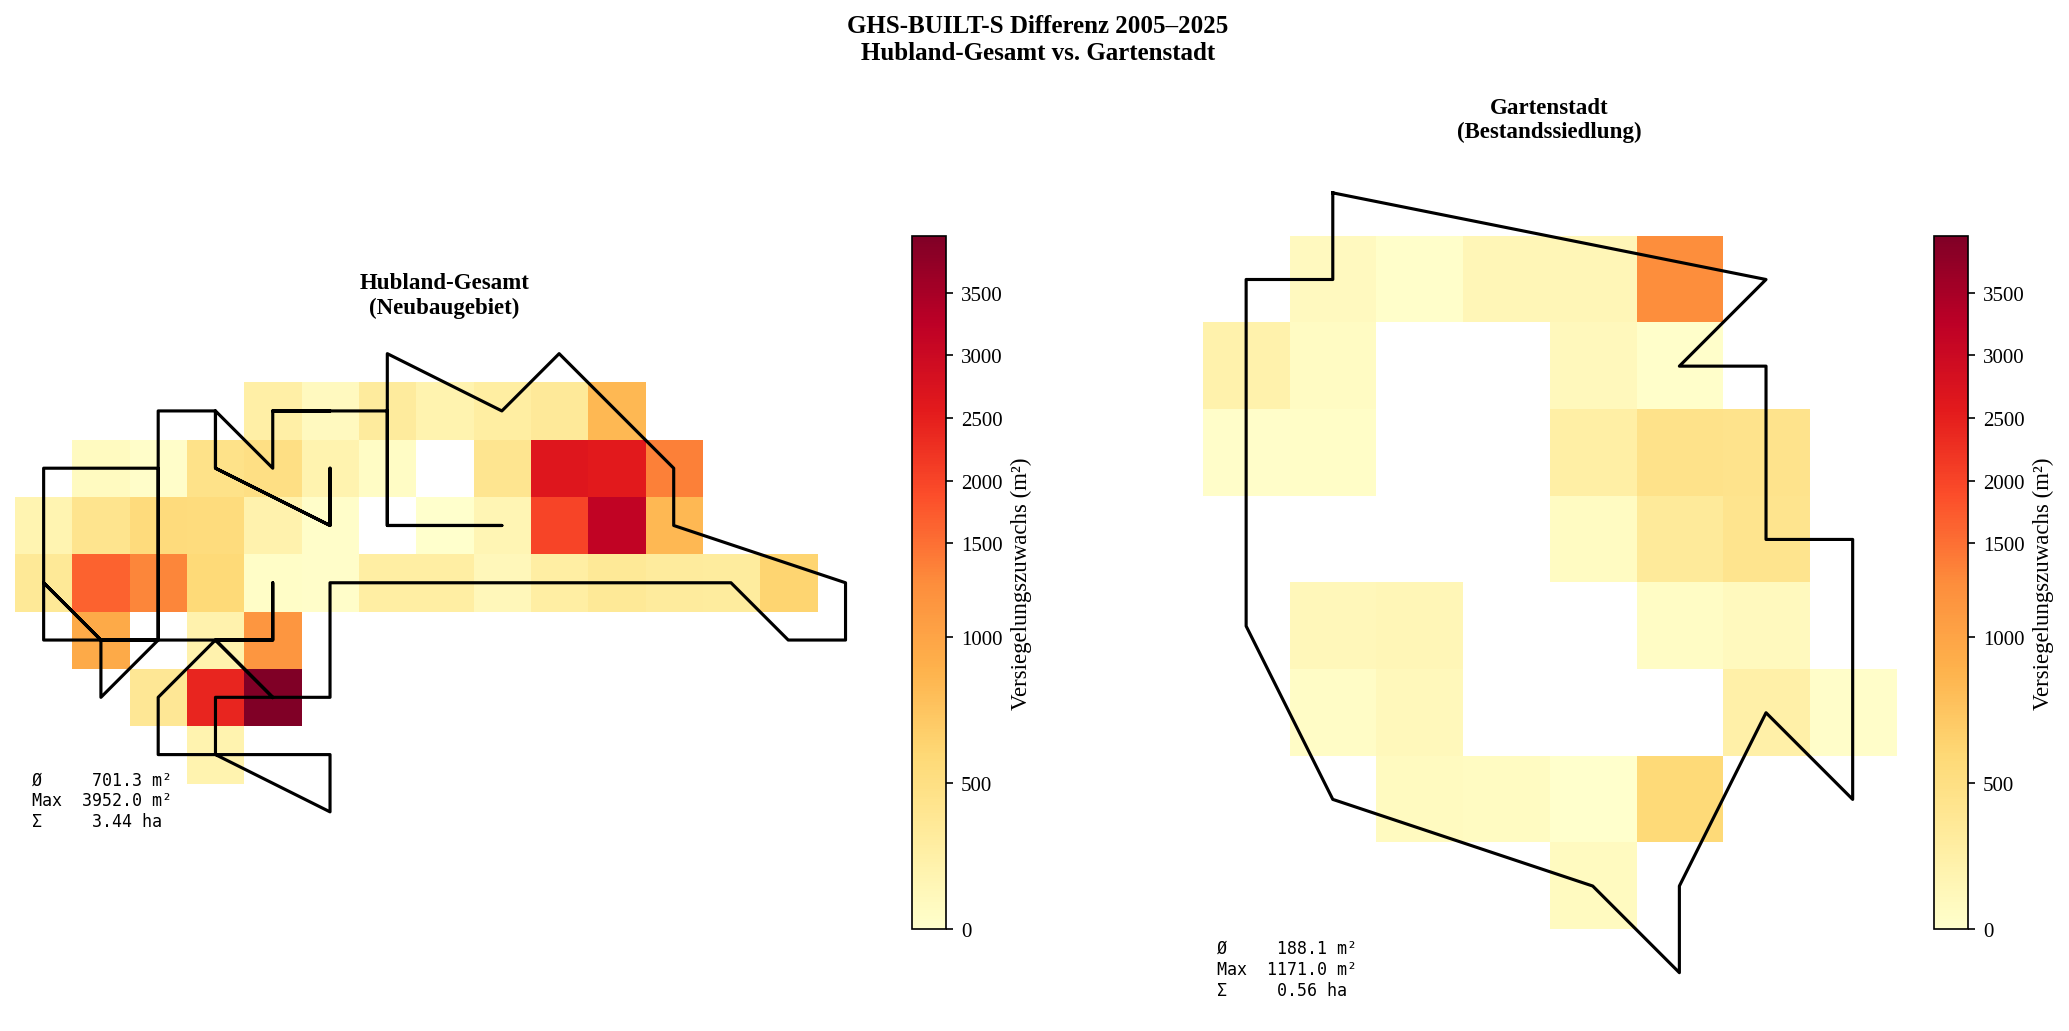

✅ Gespeichert: GHSL_Diff_Hubland-Gesamt_Gartenstadt.png


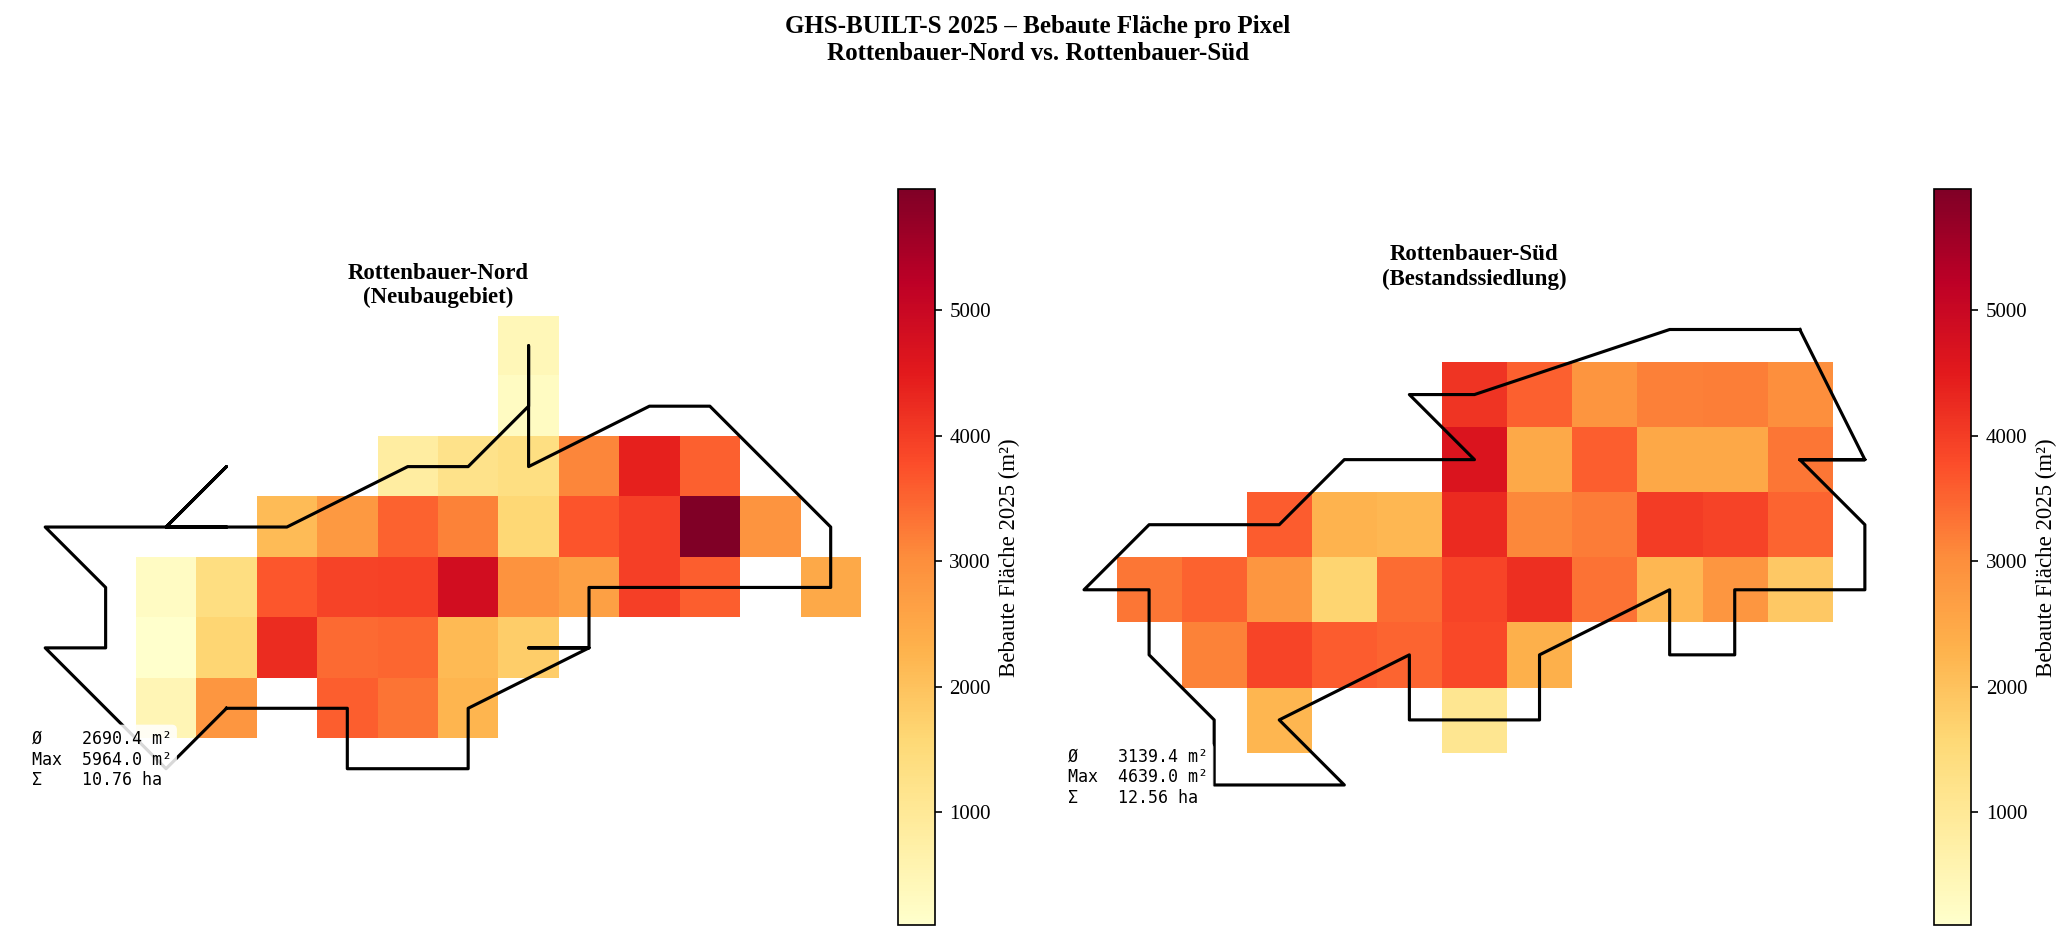

✅ Gespeichert: GHSL_2025_Rottenbauer-Nord_Rottenbauer-Süd.png


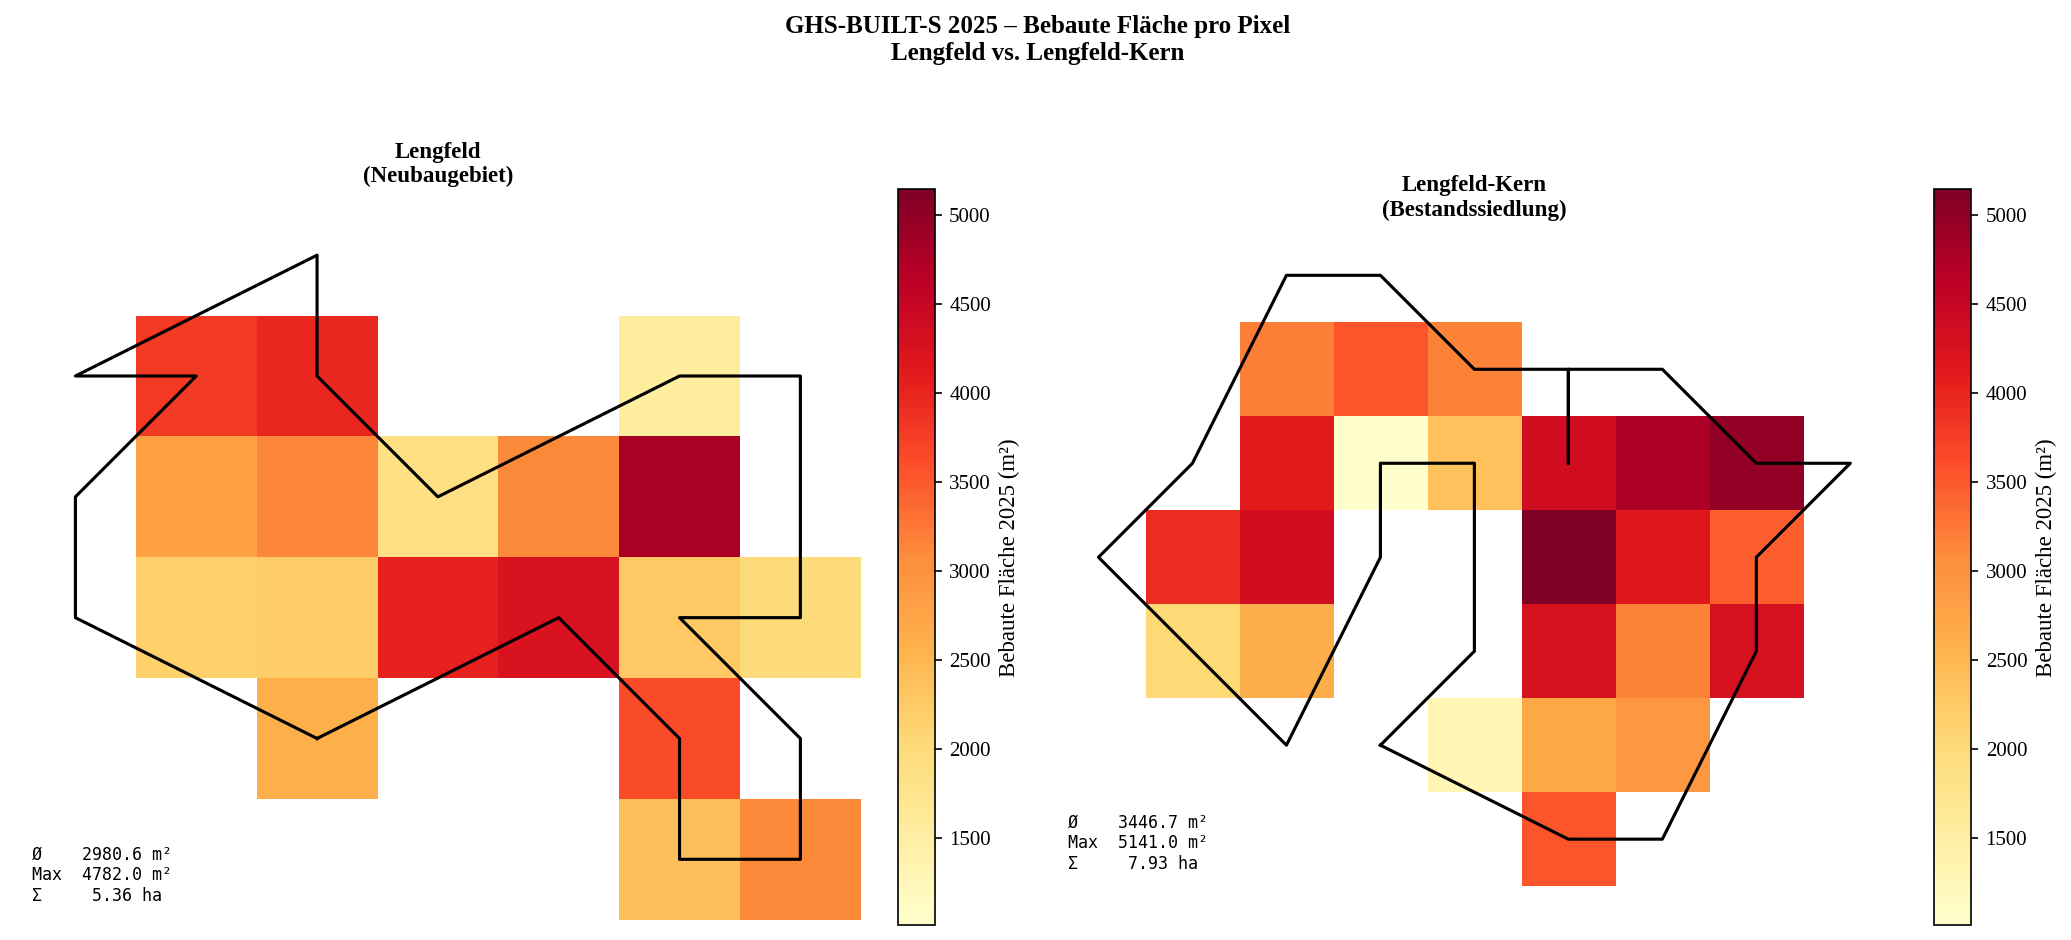

✅ Gespeichert: GHSL_2025_Lengfeld_Lengfeld-Kern.png


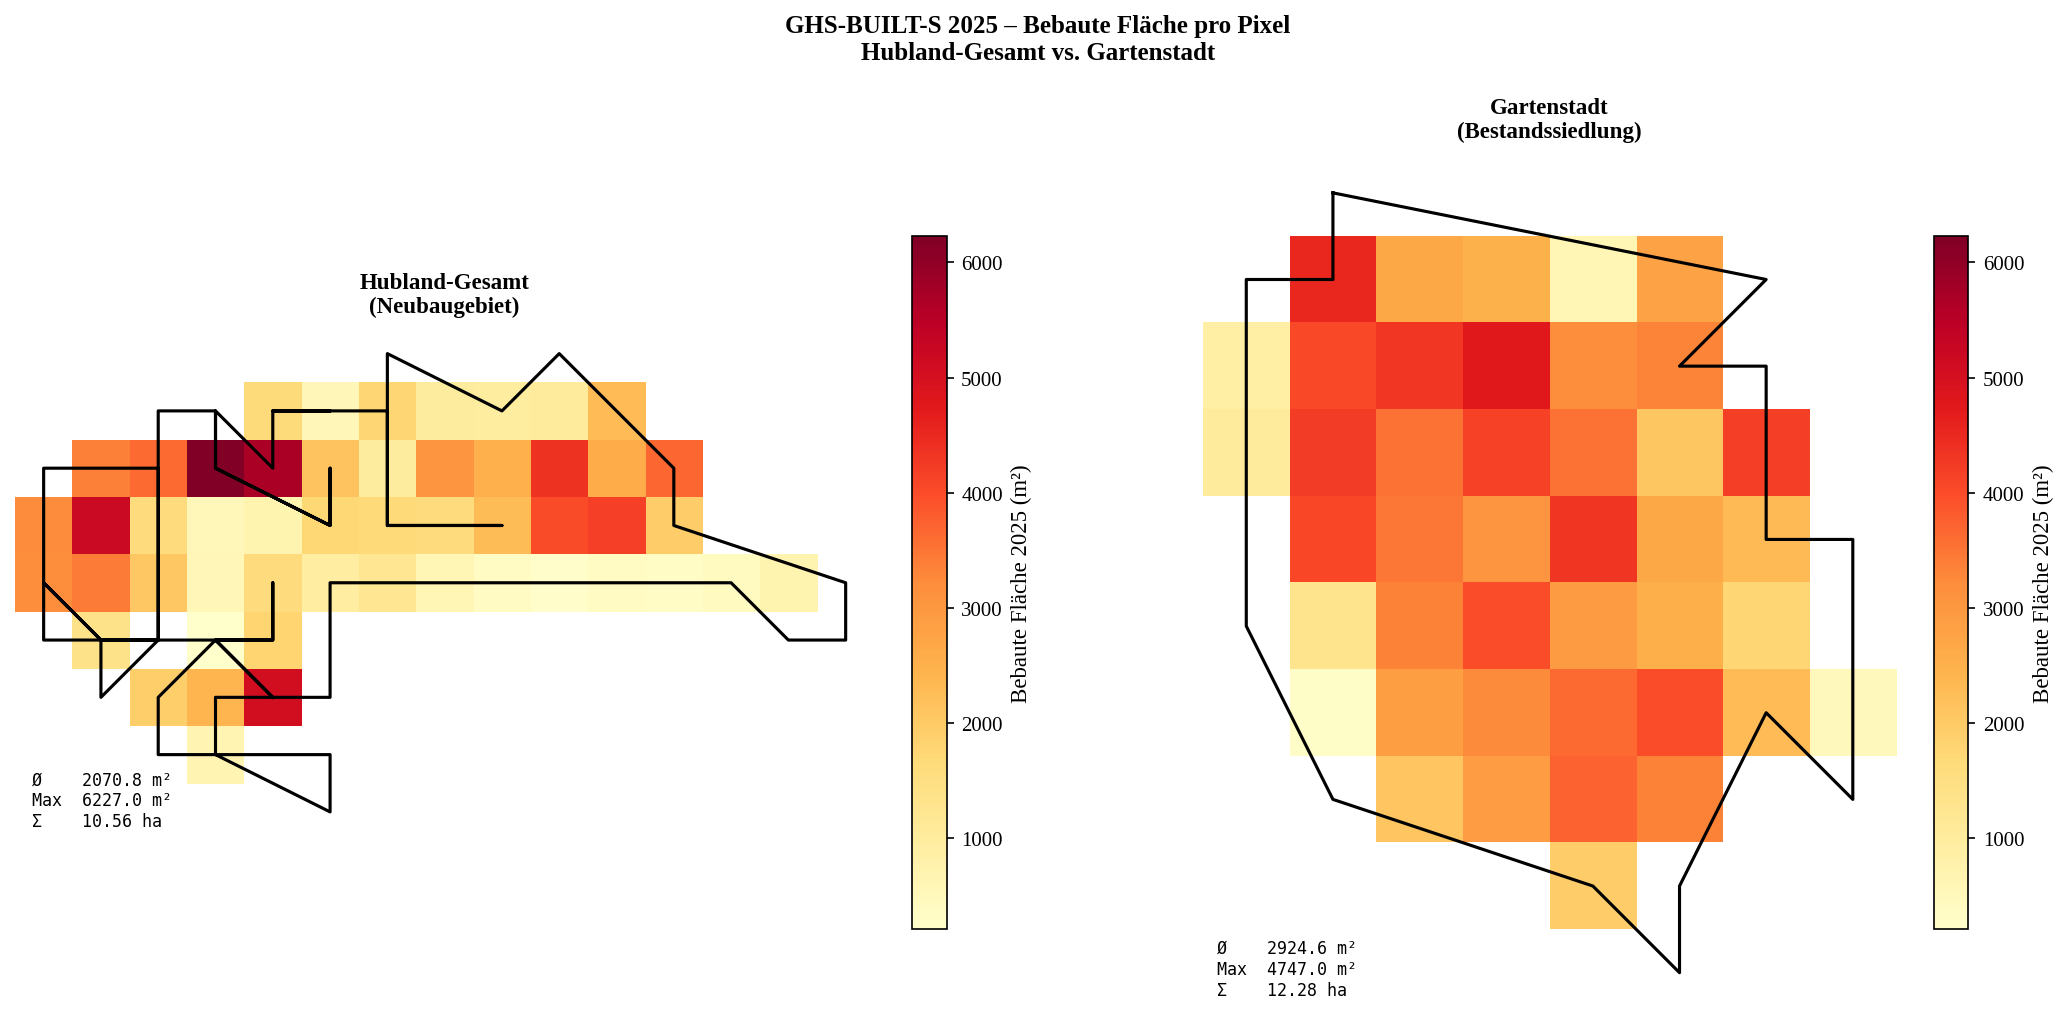

✅ Gespeichert: GHSL_2025_Hubland-Gesamt_Gartenstadt.png


In [16]:
# Manipulationcheck # Beschreibung der Gebiete # Veränderung der bebauten Fläche 2005 - 2025
# Pfade
ghsl_base  = f"{base}/GHSL/"
out_ghsl   = f"{base}/GHSL/clipped/"
os.makedirs(out_ghsl, exist_ok=True)

diff_path = os.path.join(out_ghsl, "diff_s_2025_2005_clip.tif")
path_2025 = [os.path.join(out_ghsl, f) for f in os.listdir(out_ghsl)
             if "2025" in f and f.endswith("_clip.tif")][0]

alkis_path = f"{base}/ALKIS/ALKIS_Stadt_Wue/ALKIS_Stadt_Wue.shp"
alkis = gpd.read_file(alkis_path)

#  Schritt 1: 2005 & 2025 auf Stadt-Wü clippen
ghsl_files = sorted([
    f for f in os.listdir(ghsl_base)
    if f.endswith(".tif") and ("2005" in f or "2025" in f)
])
print(f"✅ {len(ghsl_files)} GHSL-Rohdateien gefunden:")

for ghsl_file in ghsl_files:
    in_path  = os.path.join(ghsl_base, ghsl_file)
    out_path = os.path.join(out_ghsl, ghsl_file.replace(".tif", "_clip.tif"))
    with rasterio.open(in_path) as src:
        alkis_reproj        = alkis.to_crs(src.crs)
        clipped, clip_tf    = rio_mask(src, list(alkis_reproj.geometry), crop=True)
        clip_meta           = src.meta.copy()
        clip_meta.update({"height": clipped.shape[1], "width": clipped.shape[2],
                          "transform": clip_tf})
    with rasterio.open(out_path, "w", **clip_meta) as dst:
        dst.write(clipped)
    print(f"  ✔ {ghsl_file} → geclippt")

#  Schritt 2: Raster laden
def load_ghsl(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        nd  = src.nodata
    if nd is not None:
        arr[arr == nd] = np.nan
    else:
        arr[arr == 0]     = np.nan
        arr[arr == 65535] = np.nan
    return arr

path_2005 = [os.path.join(out_ghsl, f) for f in os.listdir(out_ghsl)
             if "2005" in f and f.endswith("_clip.tif")][0]
path_2025 = [os.path.join(out_ghsl, f) for f in os.listdir(out_ghsl)
             if "2025" in f and f.endswith("_clip.tif")][0]

ghsl_2005 = load_ghsl(path_2005)
ghsl_2025 = load_ghsl(path_2025)
ghsl_diff = load_ghsl(diff_path)


#  Schritt 4: Statistik pro Gebiet
def ghsl_stats(gdf, raster_path):
    with rasterio.open(raster_path) as src:
        geoms      = list(gdf.to_crs(src.crs).geometry)
        clipped, _ = rio_mask(src, geoms, crop=True, nodata=0)
    arr = clipped[0].astype(np.float32)
    arr[(arr == 0) | (arr == 65535) | (arr < 0)] = np.nan
    valid = arr[~np.isnan(arr)]
    if len(valid) == 0:
        return {"mean": np.nan, "sum": np.nan}
    return {"mean": np.nanmean(valid), "sum": np.nansum(valid)}

print(f"\n{'Gebiet':<23} {'Ø 2005':>13} {'Ø 2025':>13} {'Ø Diff':>14} "
      f"{'Σ 2005 (ha)':>13} {'Σ 2025 (ha)':>13} {'Σ Diff (ha)':>13}")
print("=" * 105)

ergebnisse_ghsl = {}
for name, gdf in gebiete_final.items():
    s2005 = ghsl_stats(gdf, path_2005)
    s2025 = ghsl_stats(gdf, path_2025)
    sdiff = ghsl_stats(gdf, diff_path)
    ergebnisse_ghsl[name] = {
        "mean_2005": s2005["mean"], "mean_2025": s2025["mean"], "mean_diff": sdiff["mean"],
        "sum_2005":  s2005["sum"],  "sum_2025":  s2025["sum"],  "sum_diff":  sdiff["sum"],
    }
    print(f"  {name:<23} "
          f"{s2005['mean']:>13.1f}  {s2025['mean']:>13.1f}  {sdiff['mean']:>+13.1f}  "
          f"{s2005['sum']/10000:>12.2f}  {s2025['sum']/10000:>12.2f}  {sdiff['sum']/10000:>+12.2f}")
print("=" * 105)

# ── Paarweise GHSL-Differenzkarten der Untersuchungsgebiete ──────────────────
from matplotlib.colors import TwoSlopeNorm
from rasterio.transform import rowcol as rc

paare = [
    ("Rottenbauer-Nord", "Rottenbauer-Süd"),
    ("Lengfeld",         "Lengfeld-Kern"),
    ("Hubland-Gesamt",   "Gartenstadt"),
]

with rasterio.open(diff_path) as src:
    raster_crs = src.crs

for neubau, bestand in paare:
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    alle_werte = []
    for name in [neubau, bestand]:
        gdf = gebiete_final[name].to_crs(raster_crs)
        with rasterio.open(diff_path) as src:
            clipped, _ = rio_mask(src, list(gdf.geometry),
                                  crop=True)
        clip_arr = clipped[0].astype(np.float32)
        clip_arr[(clip_arr == 0) | (clip_arr == 65535) | (clip_arr < 0)] = np.nan
        alle_werte.append(clip_arr)

    vmax = max(np.nanmax(a) for a in alle_werte if not np.all(np.isnan(a)))
    norm = TwoSlopeNorm(vmin=0, vcenter=vmax * 0.3, vmax=vmax)

    for ax, name, gruppe, clip_arr in [
        (axes[0], neubau,  "Neubaugebiet",    alle_werte[0]),
        (axes[1], bestand, "Bestandssiedlung", alle_werte[1]),
    ]:
        im = ax.imshow(clip_arr, cmap="YlOrRd", norm=norm)

        gdf  = gebiete_final[name].to_crs(raster_crs)
        with rasterio.open(diff_path) as src:
            _, clip_tf = rio_mask(src, list(gdf.geometry),
                                  crop=True)
        geom = gdf.geometry.union_all()
        if hasattr(geom, "exterior"):
            xs, ys = geom.exterior.coords.xy
        else:
            xs, ys = geom.convex_hull.exterior.coords.xy
        rows, cols = rc(clip_tf, xs, ys)
        ax.plot(cols, rows, color="black", linewidth=1.5)

        valid = clip_arr[~np.isnan(clip_arr)]
        if len(valid) > 0:
            stats_text = (f"Ø  {np.nanmean(valid):>8.1f} m²\n"
                          f"Max {np.nanmax(valid):>7.1f} m²\n"
                          f"Σ   {np.nansum(valid)/10_000:>6.2f} ha")
            ax.text(0.02, 0.02, stats_text,
                    transform=ax.transAxes, fontsize=8,
                    va="bottom", ha="left", family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3",
                              fc="white", alpha=0.85, ec="none"))

        plt.colorbar(im, ax=ax, label="Versiegelungszuwachs (m²)",
                     fraction=0.046, pad=0.04, shrink=0.8)
        ax.set_title(f"{name}\n({gruppe})",
                     fontsize=11, fontweight="bold", color="black")
        ax.axis("off")

    fig.suptitle(
        f"GHS-BUILT-S Differenz 2005–2025\n{neubau} vs. {bestand}",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(
        f"{grafik_dir}/GHSL_Diff_{neubau.replace(' ', '_')}_{bestand.replace(' ', '_')}.png",
        dpi=300, bbox_inches="tight", facecolor="white"
    )
    plt.show()
    print(f"✅ Gespeichert: GHSL_Diff_{neubau}_{bestand}.png")


 # ── Paarweise GHSL-2025 Karten der Untersuchungsgebiete ──────────────────────
with rasterio.open(path_2025) as src:
    raster_crs = src.crs

for neubau, bestand in paare:
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    alle_werte = []
    for name in [neubau, bestand]:
        gdf = gebiete_final[name].to_crs(raster_crs)
        with rasterio.open(path_2025) as src:
            clipped, _ = rio_mask(src, list(gdf.geometry),
                                  crop=True)
        clip_arr = clipped[0].astype(np.float32)
        nd = src.nodata
        if nd is not None:
            clip_arr[clip_arr == nd] = np.nan
        clip_arr[clip_arr == 0]     = np.nan
        clip_arr[clip_arr == 65535] = np.nan
        alle_werte.append(clip_arr)

    # Gemeinsame Farbskala über beide Gebiete
    vmax = max(np.nanmax(a) for a in alle_werte if not np.all(np.isnan(a)))
    vmin = min(np.nanmin(a) for a in alle_werte if not np.all(np.isnan(a)))

    for ax, name, gruppe, clip_arr in [
        (axes[0], neubau,  "Neubaugebiet",    alle_werte[0]),
        (axes[1], bestand, "Bestandssiedlung", alle_werte[1]),
    ]:
        im = ax.imshow(clip_arr, cmap="YlOrRd", vmin=vmin, vmax=vmax)

        # Gebietsgrenze
        gdf = gebiete_final[name].to_crs(raster_crs)
        with rasterio.open(path_2025) as src:
            _, clip_tf = rio_mask(src, list(gdf.geometry),
                                  crop=True)
        geom = gdf.geometry.union_all()
        if hasattr(geom, "exterior"):
            xs, ys = geom.exterior.coords.xy
        else:
            xs, ys = geom.convex_hull.exterior.coords.xy
        rows, cols = rc(clip_tf, xs, ys)
        ax.plot(cols, rows, color="black", linewidth=1.5)

        # Statistik
        valid = clip_arr[~np.isnan(clip_arr)]
        if len(valid) > 0:
            stats_text = (f"Ø  {np.nanmean(valid):>8.1f} m²\n"
                          f"Max {np.nanmax(valid):>7.1f} m²\n"
                          f"Σ   {np.nansum(valid)/10_000:>6.2f} ha")
            ax.text(0.02, 0.02, stats_text,
                    transform=ax.transAxes, fontsize=8,
                    va="bottom", ha="left", family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3",
                              fc="white", alpha=0.85, ec="none"))

        plt.colorbar(im, ax=ax, label="Bebaute Fläche 2025 (m²)",
                     fraction=0.046, pad=0.04, shrink=0.8)
        ax.set_title(f"{name}\n({gruppe})",
                     fontsize=11, fontweight="bold", color="black")
        ax.axis("off")

    fig.suptitle(
        f"GHS-BUILT-S 2025 – Bebaute Fläche pro Pixel\n{neubau} vs. {bestand}",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(
        f"{grafik_dir}/GHSL_2025_{neubau.replace(' ', '_')}_{bestand.replace(' ', '_')}.png",
        dpi=300, bbox_inches="tight", facecolor="white"
    )
    plt.show()
    print(f"✅ Gespeichert: GHSL_2025_{neubau}_{bestand}.png")